n_min = 1.04e-02
n_max = 7.52e-02


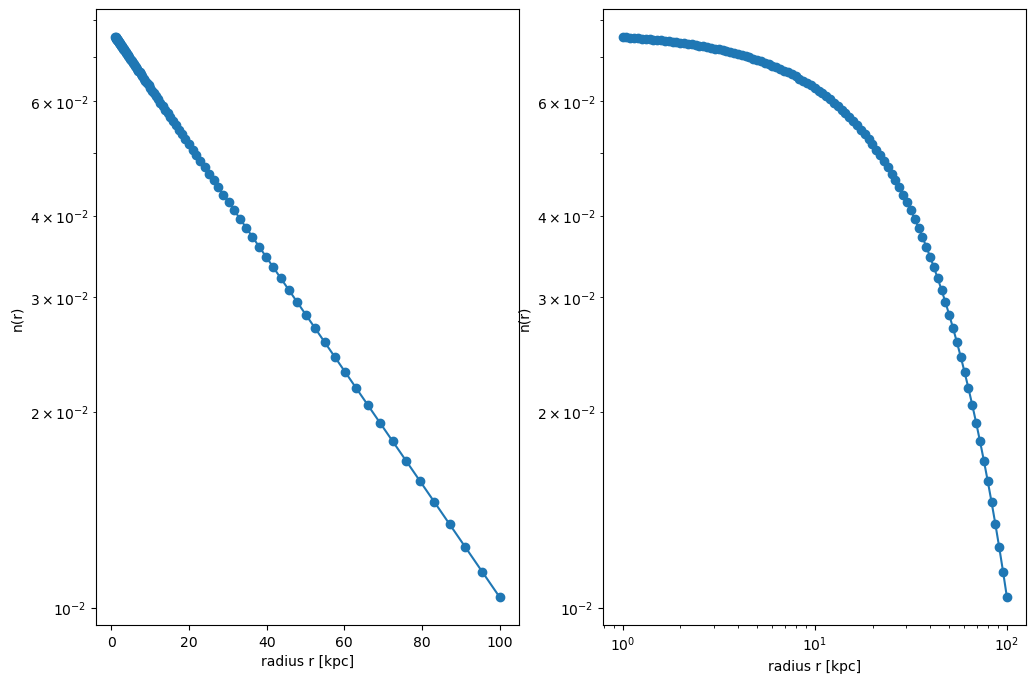

In [8]:
from RT_v1 import *
r_in  = 1.0         # [kpc]
r_out = 100.        # [kpc]
r_e   = 0.5*r_out
NHI_total = 1.0e22   # [cm^-2]
file_dlaw = 'dlaw_exp.ini'
#--------------------------------------------------

n0 = 1.0
rr = np.logspace(log10(r_in), log10(r_out), 101)

nn_exp = n0*exp(-rr/r_e)

# Scale to match the total H column density
# Analytic solution
n0_analytic = NHI_total / (exp(-r_in/r_e) - exp(-r_out/r_e)) / (r_e*kpc)

# Numerical integration for arbitrary functional form
NHI_integ = simpson(nn_exp,x=rr) * kpc
n0 = NHI_total / NHI_integ
nn_exp = n0*exp(-rr/r_e)

fig = plt.figure(1,figsize=(12,8))
# plot with linear-log space
plt.subplot(1,2,1)
plt.plot(rr, nn_exp, 'o-')
plt.xlabel(r'radius r [kpc]')
plt.ylabel(r'n(r)')
plt.yscale('log')

# plot with linear-log space
plt.subplot(1,2,2)
plt.plot(rr, nn_exp, 'o-')
plt.xlabel(r'radius r [kpc]')
plt.ylabel(r'n(r)')
plt.xscale('log')
plt.yscale('log')

# Pad one more pixel outside the r_out to include full range 
# that is specified in "radius [r_in, r_out]"
# Purely numerical reason.
rr_pad = r_out * (rr[1]/rr[0])
nn_pad = n0*exp(-rr_pad/r_e)

# Output
# for ii in range(len(rr)):
#     # print("continue {:8.5f} {:8.5f}".format(log10(rr[ii]*kpc), log10(nn_exp[ii])))
print(f'n_min = {nn_exp.min():.2e}')

print(f'n_max = {nn_exp.max():.2e}')

# print(f'n_avg = {nn_exp.mean():.2e}')



# plt.savefig('/mnt/c/Users/wlsdl/OneDrive/바탕 화면/n_H.png', bbox_inches='tight')

----------------------------------------------------------------------------------------------------
----------------------------------------------------------------------------------------------------
Lya Luminosity = 1.71e+41 [erg/s]
C IV Luminosity = 1.94e+39 [erg/s]
HeII Luminosity = 8.68e+39 [erg/s]
----------------------------------------------------------------------------------------------------
Lya Column_density = 3.18707e+20 [cm-2]
C IV Column_density = 1.50087e+16 [cm-2]
He II Column_density = 1.41248e+19 [cm-2]
----------------------------------------------------------------------------------------------------
U = -1.2848230349417757 [cm-2]
----------------------------------------------------------------------------------------------------
CIV / Lya = 0.011  (0.16)
HeII / Lya = 0.051  (0.11)


Text(0, 0.5, '$\\rm SB(R)$ $\\rm [erg \\,s^{-1} \\, cm^{-2} \\, sr^{-1}]$ ')

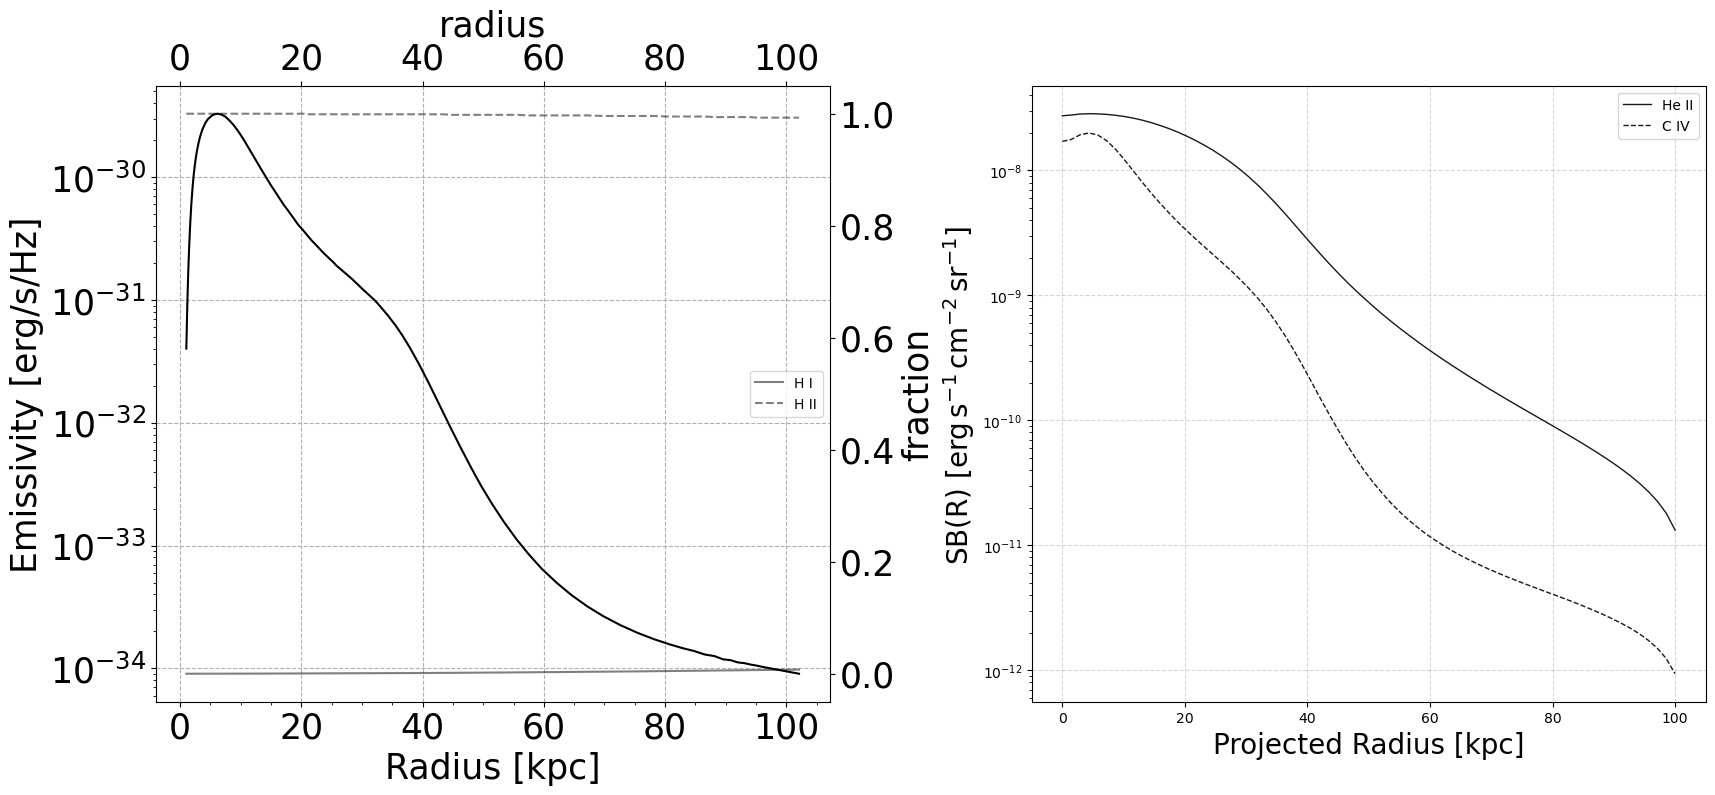

In [4]:
from RT_v1 import *

kpc = const.kpc.cgs.value


Lumin = 42.0 # 37.0 - 44.0 + 41.5, 42.5, 43.5 and 44.5
metals = 1.0 # 0.001 - 10.0
Column_density_order = 20.5 # 18.0 - 25.0
n_h_40 = (10**Column_density_order) / (40*kpc)

      
cloudy_data = CLOUDY_data_path(Lumin,metals,Column_density_order)

print('--'*50)


print('--'*50)
print(f"Lya Luminosity = {cloudy_data[f'Lumin_Lya']:.2e} [erg/s]")
print(f"C IV Luminosity = {cloudy_data[f'Lumin_CIV']:.2e} [erg/s]")
print(f"HeII Luminosity = {cloudy_data[f'Lumin_HeII']:.2e} [erg/s]")
print('--'*50)
print(f"Lya Column_density = {cloudy_data[f'Column_density_H']:.5e} [cm-2]")
print(f"C IV Column_density = {cloudy_data[f'Column_density_CIV']:.5e} [cm-2]")
print(f"He II Column_density = {cloudy_data[f'Column_density_HeII']:.5e} [cm-2]")
print('--'*50)
print(f"U = {cloudy_data[f'logU'].mean()} [cm-2]")
print('--'*50)
f_civ_lya = cloudy_data[f'Lumin_CIV'] / cloudy_data[f'Lumin_Lya']
f_heii_lya = cloudy_data[f'Lumin_HeII'] / cloudy_data[f'Lumin_Lya']

print(f"CIV / Lya = {f_civ_lya:.2}  (0.16)")
print(f"HeII / Lya = {f_heii_lya:.2}  (0.11)")
fig = plt.figure(1, figsize=(20, 8))  # 세로로 조금 더 긴 그림
gs = gridspec.GridSpec(1, 2, width_ratios=[1, 1], wspace=0.3)

# width_ratios=[2, 1]

ax1 = fig.add_subplot(gs[0])

atom = 'HeII'
# plt.plot(cloudy_data[f'radius_{Lumin}_{2}'],cloudy_data[f'emis_{atom}_{Lumin}'],'r--',label=f'{atom} without LT')
atom = 'CIV'
ax1.plot(cloudy_data[f'radius'],cloudy_data[f'emis_{atom}'],'k-',label=f'{atom} emissivity')

ax2 = fig.add_axes(ax1.get_position(), frameon=False)



plt.plot(cloudy_data[f'radius'],cloudy_data[f'frac_HI'],'k-',alpha=0.5,label=f'H I')
plt.plot(cloudy_data[f'radius'],cloudy_data[f'frac_HII'],'k--',alpha=0.5,label=f'H II')



ax1.set_xlabel('Radius [kpc]',fontsize=25)
ax1.set_ylabel('Emissivity [erg/s/Hz]',fontsize=25)
ax1.tick_params(axis='both', labelsize=25)
# ax2.set_ylabel('fraction',fontsize=25)
ax1.set_yscale('log')

ax1.minorticks_on()
ax1.grid(True,linestyle='--')


ax2.xaxis.set_ticks_position('top')
ax2.xaxis.set_label_position('top')
ax2.set_xlabel('radius', fontsize=25)

ax2.yaxis.set_ticks_position('right')
ax2.yaxis.set_label_position('right')
ax2.set_ylabel('fraction', fontsize=25)
ax2.tick_params(axis='both', labelsize=25)

plt.legend()


ax3 = fig.add_subplot(gs[1])


radius_Te_WO_LT, SB_Te_WO_LT = cloudy_data[f'radius_p'] , cloudy_data[f'SB_{atom}']

radius_Te_WO_LT, SB_Te_WO_LT_HeII = cloudy_data[f'radius_p'] , cloudy_data[f'SB_HeII']

ax3.plot(radius_Te_WO_LT, SB_Te_WO_LT_HeII,'k-',lw=1,alpha=0.9,label='He II')
ax3.plot(radius_Te_WO_LT,SB_Te_WO_LT,'k--',lw=1,alpha=0.9,label='C IV')


ax3.set_yscale('log')

ax3.legend()

ax3.grid(True,linestyle='--',alpha=0.5)

ax3.set_xlabel('Projected Radius [kpc]', fontsize=20)
ax3.set_ylabel(r'$\rm SB(R)$ $\rm [erg \,s^{-1} \, cm^{-2} \, sr^{-1}]$ ', fontsize=20)

# ax3.set_xlim(-0.1,2)
# plt.savefig('/mnt/c/Users/wlsdl/OneDrive/바탕 화면/L_45_5_NH_22_M_10', bbox_inches='tight')

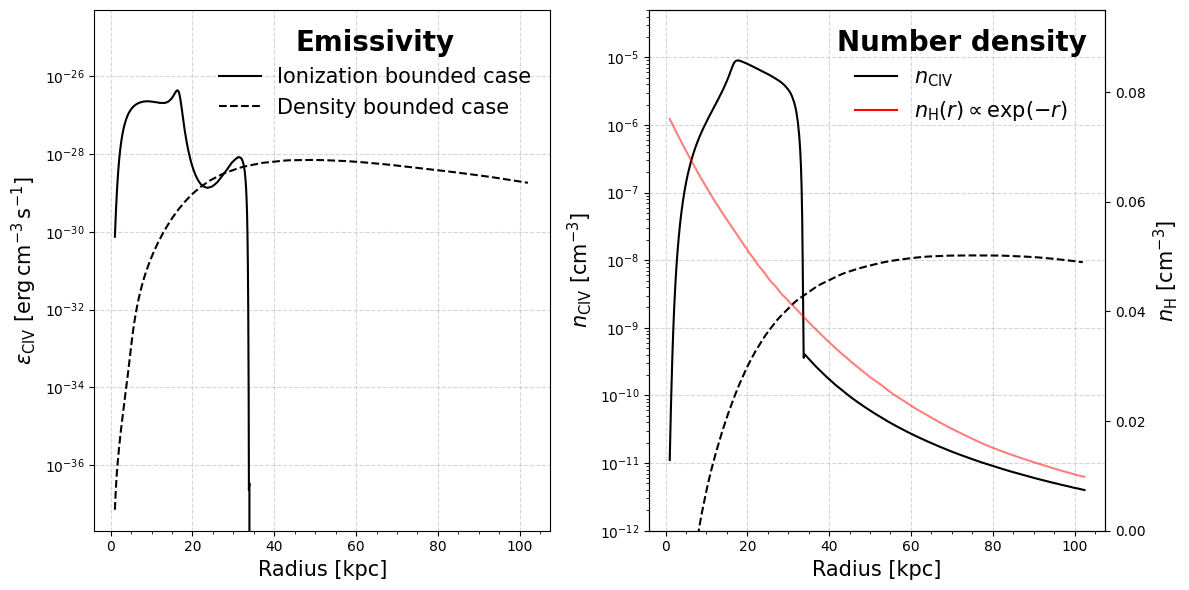

In [2]:
from RT_v1 import *

Lumin = 44.0 # 37.0 - 44.0 + 41.5, 42.5, 43.5 and 44.5
metals = 1.0 # 0.001 - 10.0
Column_density_order = 22.0 # 18.0 - 25.0
n_h_40 = (10**Column_density_order) / (40*kpc)

      
cloudy_data_440 = CLOUDY_data_path(Lumin,metals,Column_density_order)

Lumin = 46.0 
cloudy_data_460 = CLOUDY_data_path(Lumin,metals,Column_density_order)
fig = plt.figure(1,figsize=(12,6))
atom = 'CIV'

ax= plt.subplot(121)
ax.plot(cloudy_data_440['radius'], cloudy_data_440[f'emis_{atom}'], 'k-',label='Ionization bounded case') #f'$\\nu L_{{\\nu}} = 10^{{44.0}} \\, \\rm{{erg}} \\, s^{{-1}}$'
ax.plot(cloudy_data_460['radius'], cloudy_data_460[f'emis_{atom}'], 'k--',label=f'Density bounded case')

# ax.plot(cloudy_data_440['radius'], cloudy_data_440[f'emis_HeII'], 'r-',label=r"${\rm He II}$") # , label=f" $\\nu L_{{\\nu}} = 10^{{45.5}} \\, \\rm{{erg}} \\, s^{{-1}}$"
# ax.plot(cloudy_data_460['radius'], cloudy_data_460[f'emis_HeII'], 'r--') # , label=f" $\\nu L_{{\\nu}} = 10^{{45.5}} \\, \\rm{{erg}} \\, s^{{-1}}$"



ax.grid(True,linestyle='--',alpha=0.5)

ax.set_yscale('log')


ax.set_ylim(ymax=5e-25)



leg = ax.legend(
    fontsize=15,
    title=r'Emissivity',
    loc='upper right',
    title_fontproperties={'weight': 'bold', 'size': 20},
    frameon=False
)


ax.set_xlabel('Radius [kpc]',fontsize=15)
ax.set_ylabel(
    r'$\epsilon_{\rm CIV}\ \mathrm{[erg\,cm^{-3}\,s^{-1}]}$',
    fontsize=15
)


ax.minorticks_on()



ax3 = plt.subplot(122)
ax3.plot(cloudy_data_440['radius'], cloudy_data_440[f'nden_{atom}'], 'k-',label=r'$n_{\rm CIV}$')
ax3.plot(cloudy_data_460['radius'], cloudy_data_460[f'nden_{atom}'], 'k--') # , label=f" $\\nu L_{{\\nu}} = 10^{{45.5}} \\, \\rm{{erg}} \\, s^{{-1}}$"

ax3.axhline(y=1000,xmin=0,xmax=1,linestyle='-',color='r',label=r'$n_{\rm H}(r) \propto {\rm exp}{(-r)}$')

ax4 = ax3.twinx()
ax4.plot(cloudy_data_440['radius'], cloudy_data_440[f'nH'], 'r-',alpha=0.5)


leg = ax3.legend(
    fontsize=15,
    title=r'Number density',
    title_fontproperties={'weight': 'bold', 'size': 20},
    loc='upper right',
    frameon=False
)


ax3.grid(True,linestyle='--',alpha=0.5)

ax3.set_yscale('log')



ax3.set_xlabel('Radius [kpc]',fontsize=15)
ax3.set_ylabel(r'$n_{\mathrm{CIV}}\ \mathrm{[cm^{-3}]}$', fontsize=15)
ax4.set_ylabel(r'$n_{\mathrm{H}}\ \mathrm{[cm^{-3}]}$', fontsize=15)


ax3.tick_params(axis='y', labelcolor='k', labelsize=10)
ax3.tick_params(axis='x', labelcolor='k', labelsize=10)
ax3.minorticks_on()

ax4.set_ylim(ymax=0.095,ymin=0.0)
ax3.set_ylim(ymax=5e-5,ymin=1e-12)
plt.tight_layout()

# plt.savefig('/mnt/c/Users/wlsdl/OneDrive/바탕 화면/Emis_Nden.pdf', bbox_inches='tight')

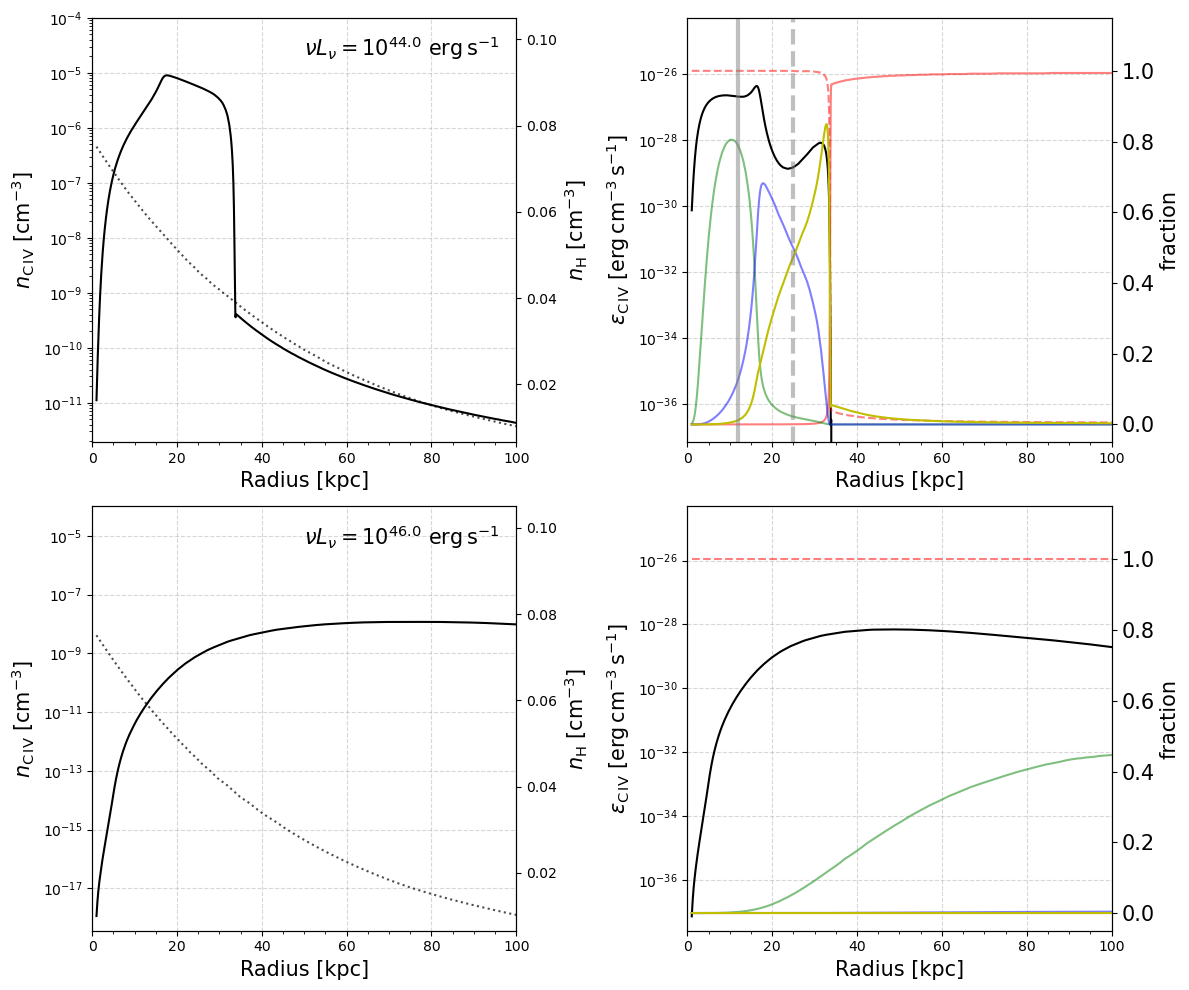

In [3]:
from RT_v1 import *

Lumin = 44.0 # 37.0 - 44.0 + 41.5, 42.5, 43.5 and 44.5
metals = 1.0 # 0.001 - 10.0
Column_density_order = 22.0 # 18.0 - 25.0
n_h_40 = (10**Column_density_order) / (40*kpc)

atom = 'CIV'

cloudy_data_440 = CLOUDY_data_path(Lumin,metals,Column_density_order)

Lumin = 46.0 
cloudy_data_460 = CLOUDY_data_path(Lumin,metals,Column_density_order)

fig = plt.figure(figsize=(12,10))

# =========================
# Right panel: Emissivity
# =========================
ax = plt.subplot(222)

ax.plot(
    cloudy_data_440['radius'],
    cloudy_data_440[f'emis_{atom}'],
    'k-',
    # label='Partially ionized H I'
)


ax.grid(True, linestyle='--', alpha=0.5)
ax.set_yscale('log')
ax.set_ylim(ymax=5e-25)

ax.set_xlabel('Radius [kpc]', fontsize=15)
ax.set_xlim(0,100)

ax.set_ylabel(
    r'$\epsilon_{\rm C\,IV}\ \mathrm{[erg\,cm^{-3}\,s^{-1}]}$',
    fontsize=15
)
ax.minorticks_on()

ax2 = ax.twinx()
ax2.plot(cloudy_data_440[f'radius'], cloudy_data_440[f'frac_HI'],'r-',alpha=0.5,label = 'C V')
ax2.plot(cloudy_data_440[f'radius'], cloudy_data_440[f'frac_HII'],'r--',alpha=0.5,label = 'C IV')

ax2.plot(cloudy_data_440[f'radius'], cloudy_data_440[f'frac_CV'],'g-',alpha=0.5,label = 'C V')
ax2.plot(cloudy_data_440[f'radius'], cloudy_data_440[f'frac_CIV'],'b-',alpha=0.5,label = 'C IV')
ax2.plot(cloudy_data_440[f'radius'],cloudy_data_440[f'frac_CIII'],'y-',label = 'C III')



ax2.axvline(x=12,ymin=0,ymax=1,lw=3,alpha=0.5,color='gray',linestyle='-')
ax2.axvline(x=25,ymin=0,ymax=1,lw=3,alpha=0.5,color='gray',linestyle='--')


# ax3.set_xlabel('Radius [kpc]',fontsize=15)
# ax3.tick_params(axis='both', labelsize=15)
# ax2.set_ylabel('fraction',fontsize=25)
# ax3.minorticks_on()
# ax3.grid(True,linestyle='--')

ax2.set_ylabel('fraction', fontsize=15)
ax2.tick_params(axis='both', labelsize=15)
ax2.set_ylim(ymax=1.15)



# ax.legend(title='Emissivity',frameon=False,title_fontsize=15)

# =========================
# Left panel: Number density
# =========================
ax3 = plt.subplot(221)

ax3.text(50,2e-5, r'$\nu L_{\nu} = 10^{44.0}\ \mathrm{erg\,s^{-1}}$',fontsize=15, fontweight='bold')

# C IV number density
ax3.plot(
    cloudy_data_440['radius'],
    cloudy_data_440[f'nden_{atom}'],
    'k-'
)

ax3.set_yscale('log')
ax3.set_ylim(ymax=1e-4)

ax3.set_xlabel('Radius [kpc]', fontsize=15)
ax3.set_xlim(0,100)

ax3.set_ylabel(
    r'$n_{\rm C\,IV}\ \mathrm{[cm^{-3}]}$',
    fontsize=15
)

ax3.grid(True, linestyle='--', alpha=0.5)
ax3.minorticks_on()

# =========================
# Secondary y-axis: Hydrogen density
# =========================
ax4 = ax3.twinx()

ax4.plot(
    cloudy_data_440['radius'],
    cloudy_data_440['nH'],
    'k:',
    # label='Hydrogen',
    alpha=0.7
)

ax4.set_ylabel(
    r'$n_{\rm H}\ \mathrm{[cm^{-3}]}$',
    fontsize=15
)
ax4.set_ylim(ymax=0.105)

# =========================
# Unified legend (left panel: Hydrogen only)
# =========================
handles4, labels4 = ax4.get_legend_handles_labels()

# ax3.legend(
#     handles4,
#     labels4,
#     title='Number density',
#     title_fontsize=15,
#     frameon=False,
#     loc='upper right'
# )

# ax3 = plt.subplot(131)




ax = plt.subplot(224)

ax.plot(
    cloudy_data_460['radius'],
    cloudy_data_460[f'emis_{atom}'],
    'k-',
    # label='Fully ionized H I'
)

ax.grid(True, linestyle='--', alpha=0.5)
ax.set_yscale('log')
ax.set_ylim(ymax=5e-25)
ax.set_xlim(0,100)

ax.set_xlabel('Radius [kpc]', fontsize=15)
ax.set_ylabel(
    r'$\epsilon_{\rm C\,IV}\ \mathrm{[erg\,cm^{-3}\,s^{-1}]}$',
    fontsize=15
)
ax.minorticks_on()

ax2 = ax.twinx()
ax2.plot(cloudy_data_460[f'radius'], cloudy_data_460[f'frac_HI'],'r-',alpha=0.5,label = 'C V')
ax2.plot(cloudy_data_460[f'radius'], cloudy_data_460[f'frac_HII'],'r--',alpha=0.5,label = 'C IV')

ax2.plot(cloudy_data_460[f'radius'], cloudy_data_460[f'frac_CV'],'g-',alpha=0.5,label = 'C V')
ax2.plot(cloudy_data_460[f'radius'], cloudy_data_460[f'frac_CIV'],'b-',alpha=0.5,label = 'C IV')
ax2.plot(cloudy_data_460[f'radius'],cloudy_data_460[f'frac_CIII'],'y-',label = 'C III')

# ax3.set_xlabel('Radius [kpc]',fontsize=15)
# ax3.tick_params(axis='both', labelsize=15)
# ax2.set_ylabel('fraction',fontsize=25)
# ax3.minorticks_on()
# ax3.grid(True,linestyle='--')

ax2.set_ylabel('fraction', fontsize=15)
ax2.set_ylim(ymax=1.15)
ax2.tick_params(axis='both', labelsize=15)




# ax.legend(title='Emissivity',frameon=False,title_fontsize=15)

# =========================
# Left panel: Number density
# =========================
ax3 = plt.subplot(223)

# C IV number density
ax3.text(50,0.5e-5, r'$\nu L_{\nu} = 10^{46.0}\ \mathrm{erg\,s^{-1}}$',fontsize=15, fontweight='bold')

ax3.plot(
    cloudy_data_460['radius'],
    cloudy_data_460[f'nden_{atom}'],
    'k-'
)

ax3.set_yscale('log')
ax3.set_ylim(ymax=1e-4)

ax3.set_xlabel('Radius [kpc]', fontsize=15)
ax3.set_xlim(0,100)
ax3.set_ylabel(
    r'$n_{\rm C\,IV}\ \mathrm{[cm^{-3}]}$',
    fontsize=15
)

ax3.grid(True, linestyle='--', alpha=0.5)
ax3.minorticks_on()

# =========================
# Secondary y-axis: Hydrogen density
# =========================
ax4 = ax3.twinx()

ax4.plot(
    cloudy_data_460['radius'],
    cloudy_data_460['nH'],
    'k:',
    # label='Hydrogen',
    alpha=0.7
)

ax4.set_ylabel(
    r'$n_{\rm H}\ \mathrm{[cm^{-3}]}$',
    fontsize=15
)
ax4.set_ylim(ymax=0.105)

# =========================
# Unified legend (left panel: Hydrogen only)
# =========================
handles4, labels4 = ax4.get_legend_handles_labels()

# ax3.legend(
#     handles4,
#     labels4,
#     title='Number density',
#     title_fontsize=15,
#     frameon=False,
#     loc='upper right'
# )

# ax3 = plt.subplot(131)




plt.tight_layout()


# plt.savefig('/mnt/c/Users/wlsdl/OneDrive/바탕 화면/Emis_Nden', bbox_inches='tight')


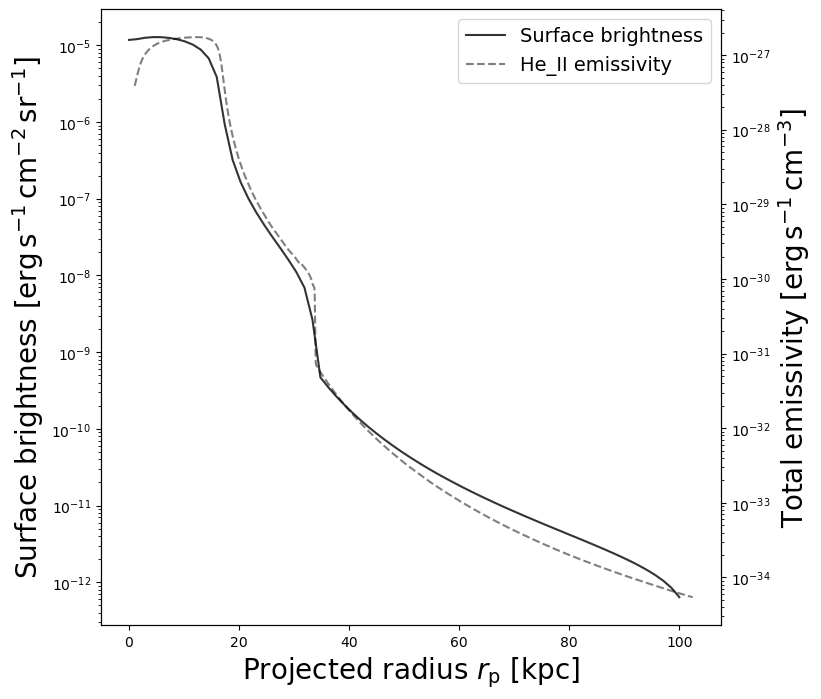

In [150]:
from RT_v1 import *


Lumin = 44.0 # 37.0 - 44.0 + 41.5, 42.5, 43.5 and 44.5
metals = 1.0 # 0.001 - 10.0
Column_density_order = 22.0 # 18.0 - 25.0

cloudy_data= CLOUDY_data_path(Lumin,metals,Column_density_order)

emis_CIV, emis_HeII = cloudy_data['emis_CIV'], cloudy_data['emis_HeII']
nden_CIV, nden_HeII = cloudy_data['nden_CIV'], cloudy_data['nden_HeII']
Te , ne, radius, radius_kpc =  cloudy_data['Te'],  cloudy_data['ne'], cloudy_data['radius'], cloudy_data['radius_kpc']

dr = abs(radius_kpc[0]-radius_kpc[1])

atom = 'HeII'
radius_p, SB_HeII= spatial_distribution_CLOUDY(atom,Lumin, metals, Column_density_order)

fig = plt.figure(1,figsize=(8,8))
ax = plt.subplot()
ax.plot(radius_p,SB_HeII,linestyle='-',alpha = 0.8, color = 'k',label='Surface brightness')
ax.set_yscale('log')
ax.set_xlabel(r'Projected radius $r_{\rm p}$ [kpc]',fontsize=20)
ax.set_ylabel(r'Surface brightness $\rm [erg \, s^{-1} \, cm^{-2}\,sr^{-1}]$',fontsize=20)

# ax.set_ylim(ymax=1e-4,ymin=1e-13)
# ax.axhline(y=1,xmin=0,xmax=1,linestyle='--',color='k',alpha=0.5,label='He_II emissivity')


ax1 = ax.twinx()
ax1.plot(radius, emis_HeII,linestyle='--',color='k',alpha=0.5,label='He_II emissivity')
ax1.set_ylabel(r'Total emissivity $\rm [erg \, s^{-1} \, cm^{-3}]$',fontsize=20)
ax1.set_yscale('log')

# 기존 두 줄의 plt.legend() 제거하고 아래로 교체

lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax1.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, fontsize=14)



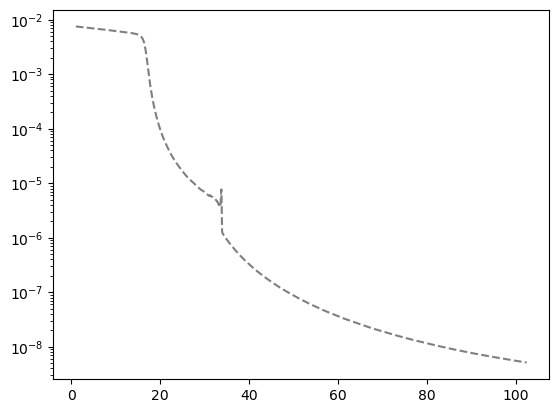

In [3]:
from RT_v1 import *
Lumin = 44.0 # 37.0 - 44.0 + 41.5, 42.5, 43.5 and 44.5
metals = 1.0 # 0.001 - 10.0
Column_density_order = 22.0 # 18.0 - 25.0

cloudy_data= CLOUDY_data_path(Lumin,metals,Column_density_order)
h_erg = h.to(u.erg*u.s).value

lam   = 1640.42e-8              # cm  (He II 1640)
nu_1640   = c_cms / lam            

hnu_1640 = h_erg * nu_1640 # erg


# ---------------------------------------------------------------------------
# 1. 데이터 불러오기
# ---------------------------------------------------------------------------
Te         = cloudy_data['Te']
ne         = cloudy_data['ne']
nH         = cloudy_data['nH']
radius = cloudy_data['radius']
radius_kpc = cloudy_data['radius_kpc']
frac_HeIII = cloudy_data['frac_HeIII']
frac_HeII  = cloudy_data['frac_HeII']
nden_HeII  = cloudy_data['nden_HeII']      # He+ (He II) number density
emis_HeII  = np.asarray(cloudy_data['emis_HeII'])   # CLOUDY 4*pi*j reference

n_HeIII = nden_HeII * (frac_HeIII / frac_HeII)
A_He = 0.1
n_test = nH*A_He*frac_HeII

term = ne*n_HeIII*hnu_1640 
eps_coeff = 2.04e-13  
# print(nu_1640)
# plt.plot(radius,term)
# plt.yscale('log')

he2 = pn.RecAtom('He', 2)
eps_coeff = he2.getEmissivity(tem=Te, den=ne, wave=1640,product=False)
term = ne*n_HeIII*hnu_1640*eps_coeff
# plt.plot(radius,term)
plt.plot(radius, n_HeIII,linestyle='--',color='k',alpha=0.5,label='He_II emissivity')
plt.yscale('log')

유효 셀: 255 / 255
ratio CLOUDY/power-law  중앙값: 0.047379310945795755
ratio CLOUDY/Z-scaling  중앙값: 0.047427769875384884


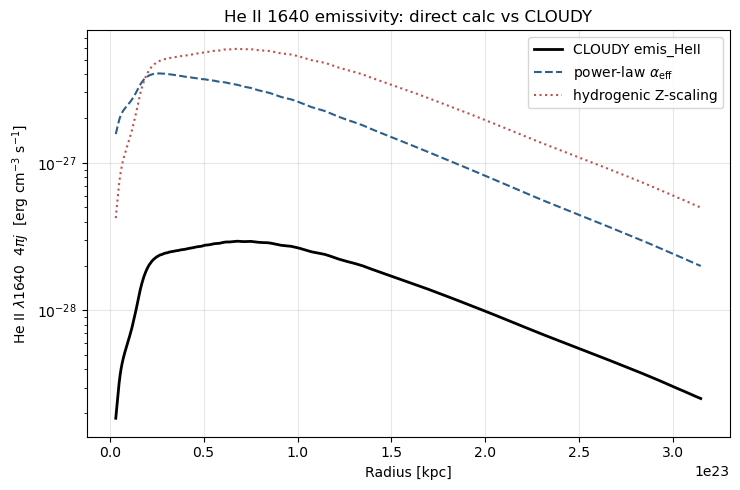

In [169]:
from RT_v1 import *
import numpy as np
import matplotlib.pyplot as plt
Lumin = 46.0 # 37.0 - 44.0 + 41.5, 42.5, 43.5 and 44.5
metals = 1.0 # 0.001 - 10.0
Column_density_order = 22.0 # 18.0 - 25.0

cloudy_data= CLOUDY_data_path(Lumin,metals,Column_density_order)
# ---------------------------------------------------------------------------
# 0. 데이터
# ---------------------------------------------------------------------------
Te         = cloudy_data['Te']
ne         = cloudy_data['ne']
radius_kpc = cloudy_data['radius_kpc']
frac_HeIII = cloudy_data['frac_HeIII']
frac_HeII  = cloudy_data['frac_HeII']
nden_HeII  = cloudy_data['nden_HeII']      # He+ (He II) number density
emis_HeII  = np.asarray(cloudy_data['emis_HeII'])   # CLOUDY 4*pi*j reference

# He III 밀도: abundance 가정 없이 CLOUDY 내부 밀도에서 직접
#   n_HeIII = n_HeII * (frac_HeIII / frac_HeII)
n_HeIII = nden_HeII * (frac_HeIII / frac_HeII)

# 물리 상수
h     = 6.62607015e-27          # erg s
c     = 2.99792458e10           # cm/s
lam   = 1640.42e-8              # cm  (He II 1640)
hnu   = h * c / lam             # erg

# ---------------------------------------------------------------------------
# 방법 A: power-law 근사
#   alpha_eff(Te) = alpha0 * (Te/T0)^(-p)
# ---------------------------------------------------------------------------
T0     = 1.0e4
alpha0 = 2.04e-13               # cm^3 s^-1, He II 1640 @ 1e4 K (SH95 Case B 근사값)
p_idx  = 0.5
alpha_eff_pl = alpha0 * (Te / T0)**(-p_idx)
emis_pl = 4*np.pi * ne * n_HeIII * alpha_eff_pl * hnu

# ---------------------------------------------------------------------------
# 방법 B: hydrogenic Z-scaling
#   alpha_eff^HeII(Te) = Z * alpha_eff^Halpha(Te / Z^2),  Z=2
#   H-alpha effective recomb coeff (Case B) - Pengelly/Hummer&Storey 계열 fit:
#   alpha_Halpha(T4) ~ 1.17e-13 * T4^(-0.942 - 0.031*ln T4)   (T4 = Te/1e4)
# ---------------------------------------------------------------------------
def alpha_Halpha(T):
    T4 = T / 1.0e4
    return 1.17e-13 * T4**(-0.942 - 0.031*np.log(T4))    # cm^3 s^-1

Z = 2
alpha_eff_zs = Z * alpha_Halpha(Te / Z**2)
emis_zs = 4*np.pi * ne * n_HeIII * alpha_eff_zs * hnu

# ---------------------------------------------------------------------------
# 유효 셀 + 정렬
# ---------------------------------------------------------------------------
mask  = np.isfinite(emis_HeII) & np.isfinite(radius_kpc) & np.isfinite(n_HeIII)
order = np.argsort(radius_kpc[mask])
r        = radius_kpc[mask][order]
e_cloudy = emis_HeII[mask][order]
e_pl     = emis_pl[mask][order]
e_zs     = emis_zs[mask][order]

print("유효 셀:", mask.sum(), "/", emis_HeII.size)
print("ratio CLOUDY/power-law  중앙값:", np.nanmedian(e_cloudy / e_pl))
print("ratio CLOUDY/Z-scaling  중앙값:", np.nanmedian(e_cloudy / e_zs))

# ---------------------------------------------------------------------------
# Plot (linear)
# ---------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(7.5, 5))
ax.plot(r, e_cloudy, lw=2.0, color="black",   label="CLOUDY emis_HeII")
ax.plot(r, e_pl,     lw=1.5, ls="--", color="#2c5f8a", label=r"power-law $\alpha_{\rm eff}$")
ax.plot(r, e_zs,     lw=1.5, ls=":",  color="#c0504d", label="hydrogenic Z-scaling")

ax.set_xlabel("Radius [kpc]")
ax.set_ylabel(r"He II $\lambda1640$  $4\pi j$  [erg cm$^{-3}$ s$^{-1}$]")
ax.set_title("He II 1640 emissivity: direct calc vs CLOUDY")
ax.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))
ax.grid(True, alpha=0.3)
ax.legend()
ax.set_yscale('log')

fig.tight_layout()
# fig.savefig("/mnt/user-data/outputs/heii1640_direct_vs_cloudy.png", dpi=150)
plt.show()